In [ ]:
"""
Design
- FD grid is used as a coordinate scaffold only. Candidate points are
  drawn from FD grid coordinates so coverage is always dense.
- u values at interior points are computed by PDE-informed interpolation,
  NOT copied from FD. FD is used only for error measurement.
- Stopping criterion: max_points successfully computed interior points.
- KDTree for O(log N) neighbour queries.
- O(1) candidate removal via swap-and-pop.
"""

import time
import numpy as np
from scipy.spatial import KDTree
from scipy.interpolate import RegularGridInterpolator

alpha = 0.05
c     = 0.5
T     = 0.5
import numpy as np

alpha = 0.05
c = 0.5

beta = c / (2 * alpha)
_N_SERIES = 200

# Precompute coefficients once
_xq = np.linspace(0.0, 1.0, 20001)
_b = np.zeros(_N_SERIES + 1)

for n in range(1, _N_SERIES + 1):
    integrand = np.exp(-beta * _xq) * np.sin(np.pi * _xq) * np.sin(n * np.pi * _xq)
    _b[n] = 2.0 * np.trapezoid(integrand, _xq)

_n_arr = np.arange(1, _N_SERIES + 1)
_bn    = _b[1:]
_lam   = -alpha * (_n_arr * np.pi) ** 2

def u_true(x, t):
    x = np.asarray(x, dtype=float)
    scalar = x.ndim == 0
    x = np.atleast_1d(x)
    sin_nx = np.sin(np.pi * np.outer(x, _n_arr))
    exp_t  = np.exp(_lam * t)
    s      = (sin_nx * (_bn * exp_t)).sum(axis=-1)
    result = np.exp(beta * x - (c**2 / (4 * alpha)) * t) * s
    return float(result[0]) if scalar else result

# ── FD r/eference grid ─────────────────────────────────────────────────────────
nx_fd = 100
x_fd  = np.linspace(0.0, 1.0, nx_fd)
dx_fd = x_fd[1] - x_fd[0]

# Compute nt_fd from CFL — never touch this manually
dt_cfl = min(0.9  * dx_fd / c,
             0.45 * dx_fd**2 / alpha)
nt_fd  = max(int(np.ceil(T / dt_cfl)) + 1, 10)
t_fd   = np.linspace(0.0, T, nt_fd)
dt_fd  = t_fd[1] - t_fd[0]



def build_fd_reference():
    """Explicit upwind FD solve. Returns (u_fd, interpolant)."""
    u = np.zeros((nx_fd, nt_fd))
    u[:, 0] = u_true(x_fd, 0.0)

    r_diff = alpha * dt_fd / dx_fd**2
    r_adv  = c     * dt_fd / dx_fd

    for it in range(nt_fd - 1):
        un = u[:, it]
        u[1:-1, it+1] = (un[1:-1]
                         - r_adv  * (un[1:-1] - un[:-2])
                         + r_diff * (un[2:] - 2*un[1:-1] + un[:-2]))
        u[0,  it+1] = 0.0
        u[-1, it+1] = 0.0

    interp = RegularGridInterpolator(
        (x_fd, t_fd), u, method='linear',
        bounds_error=False, fill_value=None
    )
    return u, interp


# ── Integrator hyperparameters ────────────────────────────────────────────────
max_points    = 200000   # stopping criterion
u_bound = 1.1
n_neighbours  = 5     # stencil size (3 equations, 5 unknowns → underdetermined)
cond_max      = 1e4
isotropy_max  = 50.0
w_max_factor  = 3.0     # reject if max|w_j| > w_max_factor / n
w_min_floor   = -1.0

# Spawn box in FD grid steps
spawn_nx      = 5       # ± x steps around a newly solved point
spawn_nt      = 3       # + t steps forward

# Neighbour search box in normalised units (x/dx_fd, t/dt_fd)
box_n0        = 2.0     # initial half-width
box_grow      = 1.5
box_nmax      = 15.0

max_candidates = 10000   # cap on candidate list length (for memory and speed)


# ── KDTree-backed visited set ─────────────────────────────────────────────────
class VisitedSet:
    """
    Stores (x, t, u) points. KDTree is in normalised (x/dx_fd, t/dt_fd)
    space so both axes are commensurate during neighbour search.
    Rebuilt lazily every rebuild_every insertions.
    """
    def __init__(self, rebuild_every=200):
        self._pts           = []
        self._norm          = []
        self._tree          = None
        self._dirty         = 0
        self._rebuild_every = rebuild_every
    def add(self, x, t, u):
        self._pts.append((x, t, u))
        self._norm.append((x / dx_fd, t / dt_fd))   # add this
        self._dirty += 1
        if self._dirty >= self._rebuild_every:
            self._rebuild()

    def _rebuild(self):
        self._tree  = KDTree(np.array(self._norm))   # change this
        self._dirty = 0

    def _ensure(self):
        if self._tree is None:
            self._rebuild()

    def find_neighbours(self, x_star, t_star):
        self._ensure()
        xn = x_star / dx_fd
        tn = t_star / dt_fd
        bn = box_n0
        while True:
            idxs = self._tree.query_ball_point([xn, tn], r=bn, p=np.inf)
            nb = [
                self._pts[i] for i in idxs
                if abs(self._pts[i][0] - x_star) <= bn * dx_fd
                and 0 < (t_star - self._pts[i][1]) <= bn * dt_fd
            ]
            if len(nb) >= n_neighbours:
                nb.sort(key=lambda p: (p[0]-x_star)**2 + (p[1]-t_star)**2)
                return nb[:n_neighbours]
            bn = min(bn * box_grow, box_nmax)
            if bn >= box_nmax:
                return None
    def __len__(self):
        return len(self._pts)
    


# ── Stencil geometry check ────────────────────────────────────────────────────
def stencil_is_good(dx_i, dt_i):
    if np.min(dx_i) * np.max(dx_i) > 0:          # two-sided coverage
        return False
    h   = max(np.max(np.abs(dx_i)), 1e-12)
    tau = max(np.max(np.abs(dt_i)), 1e-12)
    pts = np.column_stack([dx_i / h, dt_i / tau])
    return True


# ── Weight solver ─────────────────────────────────────────────────────────────
def solve_weights(dx_i, dt_i):
    """
    Min-norm lstsq on the 3×n PDE-informed system.
    Returns (w, cond) or (None, cond).
    """
    h   = max(np.max(np.abs(dx_i)), 1e-12)
    tau = max(np.max(np.abs(dt_i)), 1e-12)

    A = np.array([
        np.ones(len(dx_i)),
         (dx_i - c * dt_i)              / h,
        (0.5 * dx_i**2 + alpha * dt_i) / h**2,
    ]) 
    b = np.array([1 , 0.0, 0.0])

    cond = np.linalg.cond(A)
    if cond > cond_max:
        return None,    cond

    w = np.linalg.lstsq(A, b, rcond=None)[0]


    # Additional weight checks to prevent error explosion — these are somewhat ad-hoc and may be tuned or removed based on your needs.
    if np.max(np.abs(w)) > w_max_factor / len(dx_i):   # no dominant weight
        return None, cond
    if np.min(w) < w_min_floor:                         # no extreme negatives
        return None, cond

    return w, cond

## Add L2 instead of L1

# ── Main integrator ───────────────────────────────────────────────────────────
def run_integrator(seed=None):
    t_wall = time.time()
    if seed is not None:
        np.random.seed(seed)

    print("Building FD reference...", flush=True)
    _, fd_interp = build_fd_reference()
    print(f"  dx={dx_fd:.4f}  dt={dt_fd:.5f}", flush=True)

    # IC + BC into visited set
    visited = VisitedSet()
    for ix in range(nx_fd):
        visited.add(x_fd[ix], 0.0, u_true(x_fd[ix], 0.0))
    for it in range(1, nt_fd):
        visited.add(0.0,  t_fd[it], 0.0)
        visited.add(1.0,  t_fd[it], 0.0)
    print(f"  IC+BC points: {len(visited)}", flush=True)

    # Candidate pool — integer (ix, it) keys for O(1) deduplication
    cand_keys = set()
    cand_list = []   # list of (x, t)

    def push(ix, it):
        if (ix, it) not in cand_keys:
            cand_keys.add((ix, it))
            cand_list.append((x_fd[ix], t_fd[it]))

    # Seed from IC
    for ix in range(1, nx_fd - 1):
        for dix in range(-spawn_nx, spawn_nx + 1):
            for dit in range(1, spawn_nt + 1):
                nix, nit = ix + dix, dit
                if 1 <= nix <= nx_fd - 2 and nit < nt_fd:
                    push(nix, nit)

    print(f"  Initial candidates: {len(cand_list)}", flush=True)
    print(f"  Stopping at {max_points} computed points\n", flush=True)

    rej        = dict(proximity=0, no_nb=0, geometry=0, cond=0, weights=0)
    point_data = []

    while cand_list and len(point_data) < max_points:

        # Trim if candidate list is over budget
        protect_candidates = 500

        if len(cand_list) > max_candidates:
            target_size = max(max_candidates, protect_candidates)
            n_remove = len(cand_list) - target_size
            if n_remove > 0:
                del cand_list[:n_remove]

        # ── O(1) swap-and-pop ─────────────────────────────────────────────
        idx            = np.random.randint(len(cand_list))
        x_star, t_star = cand_list[idx]
        cand_list[idx] = cand_list[-1]
        cand_list.pop()
        ix_s = int(round(x_star / dx_fd))
        it_s = int(round(t_star / dt_fd))
        cand_keys.discard((ix_s, it_s))

        nb = visited.find_neighbours(x_star, t_star)
        if nb is None:
            rej['no_nb'] += 1
            continue

        nb_pts = np.array(nb)
        dx_i   = nb_pts[:, 0] - x_star
        dt_i   = nb_pts[:, 1] - t_star   # negative: neighbours are in the past

        if not stencil_is_good(dx_i, dt_i):
            rej['geometry'] += 1
            continue

        w, cond = solve_weights(dx_i, dt_i)
        if w is None:
            rej['cond' if cond > cond_max else 'weights'] += 1
            continue

        # Accept point  
        u_hat = float(w @ nb_pts[:, 2])

        # Break the error cascade — u is bounded by IC amplitude + margin
        if abs(u_hat) > u_bound:
            rej['bounds'] = rej.get('bounds', 0) + 1
            continue

        visited.add(x_star, t_star, u_hat)

        # Spawn new candidates in the FD grid box around this point
        for dix in range(-spawn_nx, spawn_nx + 1):
            for dit in range(1, spawn_nt + 1):
                nix = ix_s + dix
                nit = it_s + dit
                if 1 <= nix <= nx_fd - 2 and nit < nt_fd:
                    push(nix, nit)

        u_fd_ref = float(fd_interp([[x_star, t_star]])[0])
        u_true_ref = float(u_true(x_star, t_star))
 
        point_data.append({
            'x':     x_star,
            't':     t_star,
            'u':     u_hat,
            'u_true': u_true_ref,
            'u_fd':   u_fd_ref,
            'err_true': abs(u_hat - u_true_ref),
            'err_fd':   abs(u_hat - u_fd_ref),
            'err':   abs(u_hat - u_true_ref),   # use true error for stats and plotting
            'cond':  cond,
            'w1':    float(np.sum(np.abs(w))),
            'box_x': float(np.max(np.abs(dx_i))),   # ← add this
            'box_t': float(np.max(np.abs(dt_i))),   # ← add this
            'nb_x':  nb_pts[:, 0].copy(),            # ← add
            'nb_t':  nb_pts[:, 1].copy(),            # ← add
            'nb_u':  nb_pts[:, 2].copy(),            # ← add
        })

        if len(point_data) % 500 == 0:
            errs = [p['err'] for p in point_data]
            t_max = max(p['t'] for p in point_data)
            print(f"  {len(point_data):5d} pts | "
                  f"mean={np.mean(errs):.2e} | "
                  f"max={np.max(errs):.2e} | "
                  f"t_max={t_max:.3f} | "
                  f"cands={len(cand_list):5d} | "
                  f"wall={time.time()-t_wall:.1f}s",
                  flush=True)

    # Summary
    errs = np.array([p['err'] for p in point_data])
    print(f"\n{'─'*56}")
    print(f"  Computed  : {len(point_data)} points")
    print(f"  Mean err  : {errs.mean():.3e}")
    print(f"  Max  err  : {errs.max():.3e}")
    print(f"  Wall time : {time.time()-t_wall:.1f}s")
    total = sum(rej.values()) + len(point_data)
    print(f"\n  Rejections (total attempts: {total})")
    for r, n in rej.items():
        print(f"    {r:10s}: {n:6d}  ({100*n/total:.1f}%)")

    return visited, point_data, fd_interp


if __name__ == '__main__':
    visited, point_data, fd_interp = run_integrator()

Building FD reference...
  dx=0.0101  dt=0.00092
  IC+BC points: 1190
  Initial candidates: 294
  Stopping at 200000 computed points

    500 pts | mean=3.42e-05 | max=7.02e-04 | t_max=0.014 | cands= 1250 | wall=0.2s
   1000 pts | mean=5.38e-05 | max=8.45e-04 | t_max=0.026 | cands= 2292 | wall=0.5s
   1500 pts | mean=6.45e-05 | max=1.06e-03 | t_max=0.039 | cands= 2987 | wall=0.7s
   2000 pts | mean=6.88e-05 | max=1.46e-03 | t_max=0.039 | cands= 3159 | wall=1.0s
   2500 pts | mean=7.32e-05 | max=1.46e-03 | t_max=0.045 | cands= 3409 | wall=1.2s
   3000 pts | mean=7.99e-05 | max=2.70e-03 | t_max=0.049 | cands= 3839 | wall=1.5s
   3500 pts | mean=8.63e-05 | max=3.77e-03 | t_max=0.056 | cands= 4252 | wall=1.8s
   4000 pts | mean=9.61e-05 | max=3.77e-03 | t_max=0.058 | cands= 4567 | wall=2.1s
   4500 pts | mean=1.04e-04 | max=4.26e-03 | t_max=0.063 | cands= 4748 | wall=2.4s
   5000 pts | mean=1.13e-04 | max=4.26e-03 | t_max=0.063 | cands= 4898 | wall=2.7s
   5500 pts | mean=1.20e-04 | max=4.

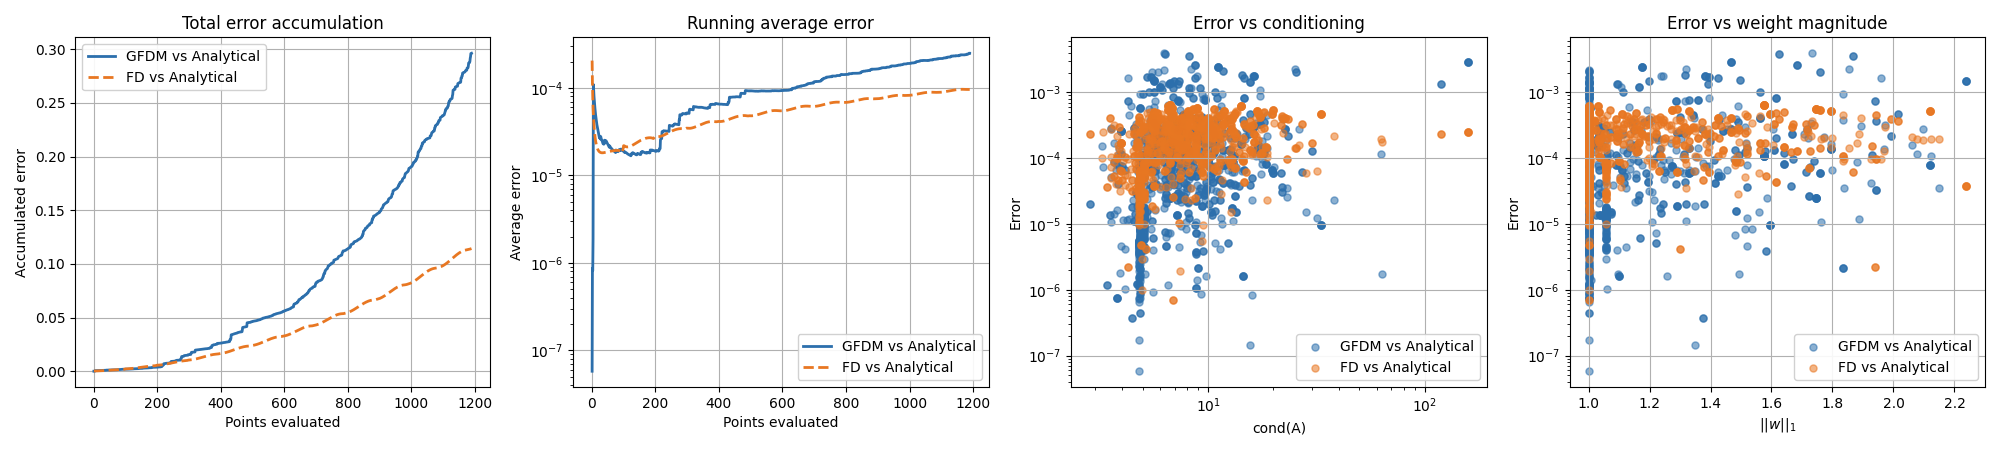

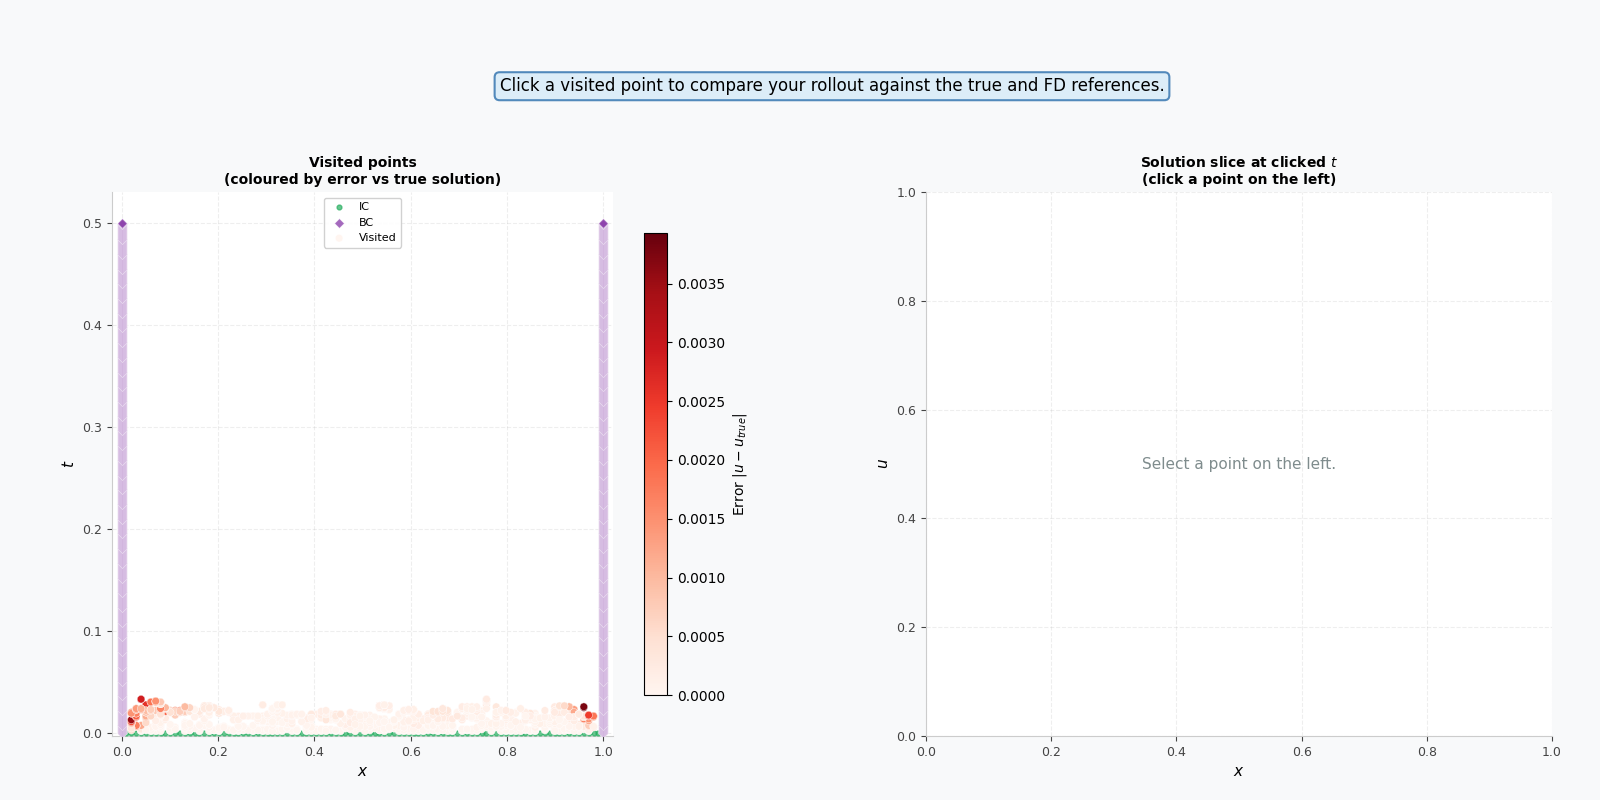

In [14]:
%matplotlib widget
import importlib
from Plots import interactive_plot as interactive_plot_module
from Plots import error_analysis as error_analysis_module

importlib.reload(interactive_plot_module)
importlib.reload(error_analysis_module)

interactive_plot = interactive_plot_module.interactive_plot
error_analysis = error_analysis_module.error_analysis

# Extract IC and BC coordinates from visited._pts
ic_x = np.array([p[0] for p in visited._pts if p[1] == 0.0 and 0 < p[0] < 1.0])
ic_t = np.array([p[1] for p in visited._pts if p[1] == 0.0 and 0 < p[0] < 1.0])

bc_x = np.array([p[0] for p in visited._pts if p[0] in [0.0, 1.0]])
bc_t = np.array([p[1] for p in visited._pts if p[0] in [0.0, 1.0]])

interactive_plot(
    point_data,
    visited._pts,   # pass the raw list so the plot code sees (x, t, u) tuples
    u_true,
    fd_interp,
    T,
    dt_fd,          # was dt_sc
    ic_x,
    ic_t,
    bc_x,
    bc_t
)

error_analysis(point_data, u_true=u_true, fd_interp=fd_interp)